# Imports / init

## Import libraries

In [ ]:
import os 

import brightway2 as bw
import lca_algebraic as agb
import numpy as np
from sympy import init_printing
import bw2io
import bw2data as bd
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd

# Pretty print for Sympy
init_printing()
bw.projects

## Init brightway2 and databases

In [ ]:
# Set the current project
# Can be any name
bw.projects.set_current('Buck-Converter-sensitivity')

# It's better to not leave credential in the code.
# Create a file named .env, that you will not share /commit, and contains the following :
ECOINVENT_LOGIN="login"
ECOINVENT_PASSWORD="password"

# This load .env file into os.environ
load_dotenv()

# This downloads ecoinvent and installs biopshere + technosphere + LCIA methods
if len(bw.databases) > 0:
    print("Initial setup already done, skipping")
   
else:
    # This is now the prefered method to init an Brightway2 with Ecoinvent
    # It is not more tied to a specific version of bw2io
    bw2io.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",
        username=ECOINVENT_LOGIN, # Read for .env file
        password=ECOINVENT_PASSWORD, # Read from .env file
        use_mp=True)
bw.databases


In [11]:
# Define the name of your new database
DB_Buck_baseline = 'BDD-Buck-baseline'
# This is better to cleanup the whole foreground model each time, and redefine it in the notebook (or a python file)
# instead of relying on a state or previous run.
# Any persistent state is prone to errors.
agb.resetDb(DB_Buck_baseline)

# Parameters are stored at project level : 
# Reset them also
# You may remove this line if you import a project and parameters from an external source (see loadParam(..))
agb.resetParams()

# Overview of the databases
agb.list_databases()

,backend,nb_activities,type
name,,,
ecoinvent-3.10-biosphere,sqlite,4362,biosphere
ecoinvent-3.10-cutoff,sqlite,23523,background
BDD-Buck-baseline,sqlite,0,foreground


## Define the impacts categories

In [12]:
# List of impacts to consider
climat = agb.findMethods("climate change", mainCat="EF v3.0")
resources = agb.findMethods("material resources: metals/minerals", mainCat="EF v3.0")
ecotox = agb.findMethods("ecotoxicity: freshwater", mainCat="EF v3.0")
impacts = [climat[0], resources[0], ecotox[0]]
#resources
#climat
impacts

[('EF v3.0', 'climate change', 'global warming potential (GWP100)'),
 ('EF v3.0',
  'material resources: metals/minerals',
  'abiotic depletion potential (ADP): elements (ultimate reserves)'),
 ('EF v3.0',
  'ecotoxicity: freshwater',
  'comparative toxic unit for ecosystems (CTUe)')]

# Create PLCA model for the baseline scenario

# Define control parameters for functional unit


In [13]:
agb.resetParams()

Y_service = agb.newFloatParam(
    'Y_service', 
    label="service provision time",
    default=30, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="service provision years")

Y_p = agb.newFloatParam(
    'Y_p', 
    label="technical lifetime of product",
    default=30, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="technical lifetime of product")

N_p_baseline = Y_service//Y_p
print(N_p_baseline)


floor(Y_service/Y_p)


## Manufacturing phase modelling
To effectively allocate manufacturing impacts to the specific functions provided by the PEC, a data structure organized around the product's technical blocks is proposed.


### Define parameters related to technical blocks manufacturing

With data for the following parameters :
1. Unit impact of component manufacturing
2. Component's size
3. Location of manufacturing site

Example:

**Define parameters for technical block i**

**Start parameters definition**

In [14]:
switching_cell= agb.newActivity(DB_Buck_baseline,
        "switching_cell", 
        "unit",
       exchanges = {
            agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666, #repair
            agb.findActivity("resistor production, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00022,
            agb.findActivity("diode production, glass-, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00007,
                 })

df_switching_cell= agb.printAct(switching_cell).sum().to_frame().T
Amount_kg_switching_cell = df_switching_cell.iloc[:, 1].tolist()
# print(Amount_kg_switching_cell)

output_filter= agb.newActivity(DB_Buck_baseline,
        "output_filter", 
        "unit",
       exchanges = {
            agb.findActivity("capacitor production, film type, for through-hole mounting", db_name="ecoinvent-3.10-cutoff"):0.0262,
            agb.findActivity("inductor production, ring core choke type", db_name="ecoinvent-3.10-cutoff"):0.2321,
            agb.findActivity("electric connector production, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.002,
            agb.findActivity("market for brass", loc="RoW", db_name="ecoinvent-3.10-cutoff"): 0.024151,
            agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.05066,
                 })

df_output_filter= agb.printAct(output_filter).sum().to_frame().T
Amount_kg_output_filter = df_output_filter.iloc[:, 1].tolist()
# print(Amount_kg_output_filter)

input_filter= agb.newActivity(DB_Buck_baseline,
        "input_filter", 
        "unit",
       exchanges = {
            agb.findActivity("capacitor production, film type, for through-hole mounting", db_name="ecoinvent-3.10-cutoff"):0.0769,
            agb.findActivity("inductor production, ring core choke type", db_name="ecoinvent-3.10-cutoff"):0.031996,
            agb.findActivity("electric connector production, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.002,
            agb.findActivity("market for brass", loc="RoW", db_name="ecoinvent-3.10-cutoff"): 0.161,
            agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.03377,
                 })

df_input_filter= agb.printAct(input_filter).sum().to_frame().T
Amount_kg_input_filter = df_input_filter.iloc[:, 1].tolist()
# print(Amount_kg_input_filter)

voltage_input_variator=agb.newActivity(DB_Buck_baseline,
        "voltage_input_variator", 
        "unit",
       exchanges = {
            agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666, #repair
            agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.016,
            agb.findActivity("resistor production, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00022,
            agb.findActivity("capacitor production, electrolyte type, < 2cm height", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00127,
                 })

df_voltage_input_variator= agb.printAct(voltage_input_variator).sum().to_frame().T
Amount_kg_voltage_input_variator = df_voltage_input_variator.iloc[:, 1].tolist()
# print(Amount_kg_voltage_input_variator)

#gate driver modelling

differential_mode_filter=agb.newActivity(DB_Buck_baseline,
        "differential_mode_filter", 
        "unit",
       exchanges = {
            agb.findActivity("capacitor production, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):4.8e-05,
                 })


df_differential_mode_filter= agb.printAct(differential_mode_filter).sum().to_frame().T
Amount_kg_differential_mode_filter = df_differential_mode_filter.iloc[:, 1].tolist()
# print(Amount_kg_differential_mode_filter)

isolated_supply_15V=agb.newActivity(DB_Buck_baseline,
        "isolated_supply_15V", 
        "unit",
       exchanges = {
            agb.findActivity("capacitor production, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00034,
            agb.findActivity("converter production, for electric passenger car", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0042, #repair
                 })


df_isolated_supply_15V= agb.printAct(isolated_supply_15V).sum().to_frame().T
Amount_kg_isolated_supply_15V = df_isolated_supply_15V.iloc[:, 1].tolist()
# print(Amount_kg_isolated_supply_15V)

control_signal_isolation=agb.newActivity(DB_Buck_baseline,
        "control_signal_isolation", 
        "unit",
       exchanges = {
            agb.findActivity("resistor production, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):1e-05,
            agb.findActivity("electric connector production, peripheral component interconnect buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0007,
            agb.findActivity("capacitor production, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):2.6e-05,
            agb.findActivity("transistor production, wired, small size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000454, #for repair
                 })


df_control_signal_isolation= agb.printAct(control_signal_isolation).sum().to_frame().T
Amount_kg_control_signal_isolation = df_control_signal_isolation.iloc[:, 1].tolist()
# print(Amount_kg_control_signal_isolation)

speed_manager=agb.newActivity(DB_Buck_baseline,
        "speed_manager", 
        "unit",
       exchanges = {
            agb.findActivity("resistor production, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00011,
                 })

df_speed_manager= agb.printAct(speed_manager).sum().to_frame().T
Amount_kg_speed_manager = df_speed_manager.iloc[:, 1].tolist()
print(Amount_kg_speed_manager)

gate_driver=agb.newActivity(DB_Buck_baseline,
        "gate_driver", 
        "unit",
       exchanges =   {     
        agb.findActivity("differential_mode_filter", db_name=DB_Buck_baseline):1,
        agb.findActivity("isolated_supply_15V", db_name=DB_Buck_baseline):1,
        agb.findActivity("control_signal_isolation", db_name=DB_Buck_baseline):1,
        agb.findActivity("speed_manager", db_name=DB_Buck_baseline):1,           
       })

Amount_kg_gate_driver = [sum(x) for x in zip(Amount_kg_differential_mode_filter,Amount_kg_isolated_supply_15V, Amount_kg_control_signal_isolation, Amount_kg_speed_manager)]

# print("weight of gate driver/kg:", Amount_kg_gate_driver)

#step generator modelling

speed_excution_CPLD=agb.newActivity(DB_Buck_baseline,
        "speed_excution_CPLD", 
        "unit",
       exchanges = {
            agb.findActivity("market for capacitor, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):5.2e-05,
            agb.findActivity("market for silicone product",loc="RoW",  db_name="ecoinvent-3.10-cutoff"):0.001, #for repair
                 })


df_speed_excution_CPLD= agb.printAct(speed_excution_CPLD).sum().to_frame().T
Amount_kg_speed_excution_CPLD = df_speed_excution_CPLD.iloc[:, 1].tolist()
# print(Amount_kg_speed_excution_CPLD)

PCB_CPLD=agb.newActivity(DB_Buck_baseline,
        "PCB_CPLD", 
        "unit",
       exchanges = {
            agb.findActivity("printed wiring board production, for through-hole mounting, Pb free surface", loc="GLO", db_name="ecoinvent-3.10-cutoff"):4550.0*1e-06,
            agb.findActivity("mounting, through-hole technology, Pb-free solder", loc="GLO", db_name="ecoinvent-3.10-cutoff"):4550.0*1e-06,
                 })

df_PCB_CPLD= agb.printAct(PCB_CPLD).sum().to_frame().T
Amount_squaremeter_PCB_CPLD= df_PCB_CPLD.iloc[:, 1].tolist()
Amount_kg_PCB_CPLD = [number * 2.88 for number in Amount_squaremeter_PCB_CPLD]
# print(Amount_kg_PCB_CPLD)


CPLD_scale_generator=agb.newActivity(DB_Buck_baseline,
        "CPLD_scale_generator", 
        "unit",
       exchanges = {
            agb.findActivity("market for resistor, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):4e-05,
            agb.findActivity("market for capacitor, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):5e-05,
            agb.findActivity("integrated circuit production, logic type", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0003, #for repair
       })

df_CPLD_scale_generator= agb.printAct(CPLD_scale_generator).sum().to_frame().T
Amount_kg_CPLD_scale_generator = df_CPLD_scale_generator.iloc[:, 1].tolist()
# print(Amount_kg_CPLD_scale_generator)

decoupling=agb.newActivity(DB_Buck_baseline,
        "decoupling", 
        "unit",
       exchanges = {
            agb.findActivity("market for capacitor, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000208,
       })

df_decoupling= agb.printAct(decoupling).sum().to_frame().T
Amount_kg_decoupling = df_decoupling.iloc[:, 1].tolist()
# print(Amount_kg_decoupling)

interface_gate_driver=agb.newActivity(DB_Buck_baseline,
        "interface_gate_driver", 
        "unit",
       exchanges = {
            agb.findActivity("market for electric connector, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.004,#for repair
                       agb.findActivity("market for electric connector, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.01814,#for repair
                       agb.findActivity("market for cable, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0084,#for repair
       })

df_interface_gate_driver= agb.printAct(interface_gate_driver).sum().to_frame().T
Amount_kg_interface_gate_driver = df_interface_gate_driver.iloc[:, 1].tolist()
# print(Amount_kg_interface_gate_driver)

interface_supply=agb.newActivity(DB_Buck_baseline,
        "interface_supply", 
        "unit",
       exchanges = {
            agb.findActivity("market for cable, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00021,
            agb.findActivity("market for electric connector, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.004,
       })

df_interface_supply= agb.printAct(interface_supply).sum().to_frame().T
Amount_kg_interface_supply = df_interface_supply.iloc[:, 1].tolist()
# print(Amount_kg_interface_supply)

interface_programmation=agb.newActivity(DB_Buck_baseline,
        "interface_programmation", 
        "unit",
       exchanges = {
            agb.findActivity("market for capacitor, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):5.2e-05,
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0001215,
            agb.findActivity("market for electric connector, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001,
       })

df_interface_programmation= agb.printAct(interface_programmation).sum().to_frame().T
Amount_kg_interface_programmation = df_interface_programmation.iloc[:, 1].tolist()
# print(Amount_kg_interface_programmation)

interface_switching=agb.newActivity(DB_Buck_baseline,
        "interface_switching", 
        "unit",
       exchanges = {
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0001215,
            agb.findActivity("market for electric connector, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0001215,
            agb.findActivity("market for electric connector, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001,
       })

df_interface_switching= agb.printAct(interface_switching).sum().to_frame().T
Amount_kg_interface_switching = df_interface_switching.iloc[:, 1].tolist()
# print(Amount_kg_interface_switching)

interface_LED=agb.newActivity(DB_Buck_baseline,
        "interface_LED", 
        "unit",
       exchanges = {
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000162,
            agb.findActivity("market for light emitting diode", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0018160000000000001,
       })


df_interface_LED= agb.printAct(interface_LED).sum().to_frame().T
Amount_kg_interface_LED = df_interface_LED.iloc[:, 1].tolist()
# print(Amount_kg_interface_LED)

voltage_regulation_3V=agb.newActivity(DB_Buck_baseline,
        "voltage_regulation_3V", 
        "unit",
       exchanges = {
            agb.findActivity("market for capacitor, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000104,
            agb.findActivity("market for integrated circuit, logic type", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00013000000000000002, #repair
       })


df_voltage_regulation_3V= agb.printAct(voltage_regulation_3V).sum().to_frame().T
Amount_kg_voltage_regulation_3V = df_voltage_regulation_3V.iloc[:, 1].tolist()
# print(Amount_kg_voltage_regulation_3V)

synchro_oscillo=agb.newActivity(DB_Buck_baseline,
        "synchro_oscillo", 
        "unit",
       exchanges = {
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):8e-05,
            agb.findActivity("market for cable, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00039000000000000005,
            agb.findActivity("market for electric connector, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001,
            agb.findActivity("market for electric connector, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.002,
            agb.findActivity("market for diode, glass-, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00021, #repair
       })


df_synchro_oscillo= agb.printAct(synchro_oscillo).sum().to_frame().T
Amount_kg_synchro_oscillo = df_synchro_oscillo.iloc[:, 1].tolist()
# print(Amount_kg_synchro_oscillo)

step_generator=agb.newActivity(DB_Buck_baseline,
        "step_generator", 
        "unit",
       exchanges = {
            agb.findActivity("speed_excution_CPLD", db_name=DB_Buck_baseline):1,
            agb.findActivity("PCB_CPLD", db_name=DB_Buck_baseline):1,
            agb.findActivity("CPLD_scale_generator", db_name=DB_Buck_baseline):1,
            agb.findActivity("interface_Gate_driver", db_name=DB_Buck_baseline):1,
            agb.findActivity("interface_supply", db_name=DB_Buck_baseline):1,
            agb.findActivity("interface_programmation", db_name=DB_Buck_baseline):1,
            agb.findActivity("interface_switching", db_name=DB_Buck_baseline):1,
            agb.findActivity("interface_LED", db_name=DB_Buck_baseline):1,
            agb.findActivity("voltage_regulation_3V", db_name=DB_Buck_baseline):1,
            agb.findActivity("synchro_oscillo", db_name=DB_Buck_baseline):1,
                 })

Amount_kg_step_generator = [sum(x) for x in zip(Amount_kg_speed_excution_CPLD, Amount_kg_PCB_CPLD,Amount_kg_CPLD_scale_generator,Amount_kg_interface_gate_driver,Amount_kg_interface_supply,Amount_kg_interface_programmation,Amount_kg_interface_switching,Amount_kg_interface_LED,Amount_kg_voltage_regulation_3V,Amount_kg_synchro_oscillo)]

# print("weight of step_generator/kg:", Amount_kg_step_generator)

load_resistors=agb.newActivity(DB_Buck_baseline,
        "load_resistors", 
        "unit",
       exchanges = {
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.19998,
            agb.findActivity("market for cast iron", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0384,
       })

df_load_resistors= agb.printAct(load_resistors).sum().to_frame().T
Amount_kg_load_resistors = df_load_resistors.iloc[:, 1].tolist()
# print(Amount_kg_load_resistors)

load_scaling_control=agb.newActivity(DB_Buck_baseline,
        "load_scaling_control", 
        "unit",
       exchanges = {
            agb.findActivity("market for cast iron", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0096,
            agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666, #repair
       })

df_load_scaling_control= agb.printAct(load_scaling_control).sum().to_frame().T
Amount_kg_load_scaling_control = df_load_scaling_control.iloc[:, 1].tolist()
# print(Amount_kg_load_scaling_control)

load_scaling_control=agb.newActivity(DB_Buck_baseline,
        "load_scaling_control", 
        "unit",
       exchanges = {
            agb.findActivity("market for cast iron", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0096,
            agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666, #repair
       })

df_load_scaling_control= agb.printAct(load_scaling_control).sum().to_frame().T
Amount_kg_load_scaling_control = df_load_scaling_control.iloc[:, 1].tolist()
# print(Amount_kg_load_scaling_control)

PCB=agb.newActivity(DB_Buck_baseline,
        "PCB", 
        "unit",
       exchanges = {
            agb.findActivity("printed wiring board production, for through-hole mounting, Pb free surface", loc="GLO", db_name="ecoinvent-3.10-cutoff"):35605.0*1e-06,
            agb.findActivity("mounting, through-hole technology, Pb-free solder", loc="GLO", db_name="ecoinvent-3.10-cutoff"):35605.0*1e-06,
       })

df_PCB= agb.printAct(PCB).sum().to_frame().T
Amount_squaremeter_PCB= df_PCB.iloc[:, 1].tolist()
Amount_kg_PCB = [number * 2.88 for number in Amount_squaremeter_PCB_CPLD]
# print(Amount_kg_PCB)

#modeling signal treatment
captor_PHS=agb.newActivity(DB_Buck_baseline,
        "captor_PHS", 
        "unit",
       exchanges = {
            agb.findActivity("transistor production, wired, small size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000299, #repair
            agb.findActivity("resistor production, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0006,
            agb.findActivity("resistor production, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00189,
            agb.findActivity("capacitor production, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00224,
            agb.findActivity("electric connector production, peripheral component interconnect buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.006,
       })

df_captor_PHS= agb.printAct(captor_PHS).sum().to_frame().T
Amount_kg_captor_PHS = df_captor_PHS.iloc[:, 1].tolist()
# print(Amount_kg_captor_PHS)

signal_treatment=agb.newActivity(DB_Buck_baseline,
        "signal_treatment", 
        "unit",
       exchanges = {
            agb.findActivity("captor_PHS", db_name=DB_Buck_baseline):2,
       })

Amount_kg_signal_treatment = [sum(x) for x in zip(Amount_kg_captor_PHS,Amount_kg_captor_PHS)]
                              
# print("weight of signal_treatment/kg:", Amount_kg_signal_treatment)

microprocessor_arduino=agb.newActivity(DB_Buck_baseline,
        "microprocessor_arduino", #all block repair
        "unit",
       exchanges = {
            agb.findActivity("market for capacitor, electrolyte type, < 2cm height", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0004,
            agb.findActivity("market for capacitor, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000176,
            agb.findActivity("market for diode, glass-, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):3.5e-05,
            agb.findActivity("market for electric connector, peripheral component interconnect buss", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00212,
            agb.findActivity("market for electronic component, passive, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000157,
            agb.findActivity("market for ferrite", loc="GLO", db_name="ecoinvent-3.10-cutoff"):1e-05,
            agb.findActivity("market for integrated circuit, logic type", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.000289,
            agb.findActivity("market for integrated circuit, memory type", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.00037,
            agb.findActivity("market for light emitting diode", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0002,
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):2e-05,
            agb.findActivity("market for transistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"):6.5e-05,
            agb.findActivity("market for switch, toggle type", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0001,
            agb.findActivity("printed wiring board production, for through-hole mounting, Pb free surface", loc="GLO", db_name="ecoinvent-3.10-cutoff"):864.0*1e-06,
            agb.findActivity("mounting, through-hole technology, Pb-free solder", loc="GLO", db_name="ecoinvent-3.10-cutoff"):864.0*1e-06,       })

df_microprocessor_arduino= agb.printAct(microprocessor_arduino).sum().to_frame().T
Amount_kg_microprocessor_arduino = df_microprocessor_arduino.iloc[:, 1].tolist()
# print(Amount_kg_microprocessor_arduino)

foots=agb.newActivity(DB_Buck_baseline,
        "foots", 
        "unit",
       exchanges = {
            agb.findActivity("market for acrylonitrile-butadiene-styrene copolymer", db_name="ecoinvent-3.10-cutoff"):0.0672,
            agb.findActivity("market for cast iron", db_name="ecoinvent-3.10-cutoff"):0.0075,          
       })

df_foots= agb.printAct(foots).sum().to_frame().T
Amount_kg_foots = df_foots.iloc[:, 1].tolist()
# print(Amount_kg_foots)

al_plate=agb.newActivity(DB_Buck_baseline,
        "al_plate", 
        "unit",
       exchanges = {
            agb.findActivity("market for aluminium, cast alloy", db_name="ecoinvent-3.10-cutoff"):1.5581580000000002,   
       })

df_al_plate= agb.printAct(al_plate).sum().to_frame().T
Amount_kg_al_plate = df_al_plate.iloc[:, 1].tolist()
# print(Amount_kg_al_plate)


#interface LED
LED_interface_system =  agb.newActivity(DB_Buck_baseline,
        "LED_interface_system", 
        "unit",
       exchanges = {
            agb.findActivity("market for resistor, surface-mounted", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 4e-5,
           agb.findActivity("light emitting diode production", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001588})

df_LED_interface_system= agb.printAct(LED_interface_system).sum().to_frame().T
Amount_kg_LED_interface_system = df_LED_interface_system.iloc[:, 1].tolist()
# print(Amount_kg_LED_interface_system)


#internal wiring and interface connectors subparts
input_output_interfaces_GD =agb.newActivity(DB_Buck_baseline,
        "input_output_interfaces_GD", 
        "unit",
        exchanges = {agb.findActivity("electric connector production, peripheral component interconnect buss", loc = "GLO", db_name="ecoinvent-3.10-cutoff") : 0.0003743,
        agb.findActivity("electric connector production, peripheral component interconnect buss", loc = "GLO", db_name="ecoinvent-3.10-cutoff") : 0.0003743})

df_input_output_interfaces_GD= agb.printAct(input_output_interfaces_GD).sum().to_frame().T
Amount_kg_input_output_interfaces_GD = df_input_output_interfaces_GD.iloc[:, 1].tolist()
# print(Amount_kg_input_output_interfaces_GD)


interface_phs = agb.newActivity(DB_Buck_baseline,
        "interface_phs", 
        "unit",
        exchanges = {agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.026})


df_interface_phs= agb.printAct(interface_phs).sum().to_frame().T
Amount_kg_interface_phs = df_interface_phs.iloc[:, 1].tolist()
# print(Amount_kg_interface_phs)


electrical_connexions_mc = agb.newActivity(DB_Buck_baseline,
        "electrical_connexions_mc", 
        "unit",
        exchanges = {agb.findActivity("market for brass", loc="CH", db_name="ecoinvent-3.10-cutoff" ): 0.008,
                    agb.findActivity("cable production, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.0569,
                    agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.0092})

df_electrical_connexions_mc= agb.printAct(electrical_connexions_mc).sum().to_frame().T
Amount_kg_electrical_connexions_mc = df_electrical_connexions_mc.iloc[:, 1].tolist()
# print(Amount_kg_electrical_connexions_mc)

other_module_connexion= agb.newActivity(DB_Buck_baseline,
        "other_module_connexion", 
        "unit",
        exchanges = {agb.findActivity("market for cast iron", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.0144,
                    agb.findActivity("cable production, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.0014,
                    agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.072})

df_other_module_connexion= agb.printAct(other_module_connexion).sum().to_frame().T
Amount_kg_other_module_connexion = df_other_module_connexion.iloc[:, 1].tolist()
# print(Amount_kg_other_module_connexion)

microprocessor_interface = agb.newActivity(DB_Buck_baseline,
        "microprocessor_interface", 
        "unit",
        exchanges = {agb.findActivity("electric connector production, peripheral component interconnect buss", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00427})

df_microprocessor_interface= agb.printAct(microprocessor_interface).sum().to_frame().T
Amount_kg_microprocessor_interface = df_microprocessor_interface.iloc[:, 1].tolist()
# print(Amount_kg_microprocessor_interface)

internal_wiring = agb.newActivity(DB_Buck_baseline,
        "Internal wiring & interface connector", 
        "unit",
        exchanges = {input_output_interfaces_GD : 1,
                     interface_phs : 1,
                     electrical_connexions_mc : 1,
                     other_module_connexion : 1,
                     microprocessor_interface : 1})

Amount_kg_internal_wiring = [sum(x) for x in zip(Amount_kg_input_output_interfaces_GD, Amount_kg_interface_phs,Amount_kg_electrical_connexions_mc,Amount_kg_other_module_connexion,Amount_kg_microprocessor_interface)]

# print("weight of internal_wiring/kg:", Amount_kg_internal_wiring)

#connectors & oscilloscop synchronisation   subparts

output_voltage_control_ima= agb.newActivity(DB_Buck_baseline,
        "output_voltage_control_ima", 
        "unit",
        exchanges = {agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.008,
                    agb.findActivity("electric connector production, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.01,
                    agb.findActivity("switch production, toggle type", loc="RoW", db_name="ecoinvent-3.10-cutoff" ): 0.0062,
                    agb.findActivity("potentiometer production, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.022})

df_output_voltage_control_ima= agb.printAct(output_voltage_control_ima).sum().to_frame().T
Amount_kg_output_voltage_control_ima = df_output_voltage_control_ima.iloc[:, 1].tolist()
# print(Amount_kg_output_voltage_control_ima)

alimentation_15V_ima= agb.newActivity(DB_Buck_baseline,
        "alimentation_15V_ima", 
        "unit",
        exchanges = {agb.findActivity("cable production, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00039,
                    agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.002})


df_alimentation_15V_ima= agb.printAct(alimentation_15V_ima).sum().to_frame().T
Amount_kg_alimentation_15V_ima = df_alimentation_15V_ima.iloc[:, 1].tolist()
# print(Amount_kg_alimentation_15V_ima)

command_interface_ima= agb.newActivity(DB_Buck_baseline,
        "command_interface_ima", 
        "unit",
        exchanges = {agb.findActivity("cable production, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00028,
                    agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.004})

df_command_interface_ima= agb.printAct(command_interface_ima).sum().to_frame().T
Amount_kg_command_interface_ima = df_command_interface_ima.iloc[:, 1].tolist()
# print(Amount_kg_command_interface_ima)

#size of diode is changed in case of robust design
#diode_ima_value = agb.switchValue(TechnoParam, Baseline=0.00272,  Repair = 0.00272, Enhanced_Repair = 0.00272,
                               # Robust = 0.00272 * oversizing, GaN =0.00272, Combined =0.00272 * oversizing, Optimised =0.000125*oversizing)

measure_interfaces_ima= agb.newActivity(DB_Buck_baseline,
        "measure_interfaces_ima", 
        "unit",
        exchanges = {agb.findActivity("diode production, glass-, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 2*0.00272, #diode ima value
                    agb.findActivity("resistor production, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.000011*2,
                     agb.findActivity("capacitor production, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.0000064*2,
                         agb.findActivity("cable production, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 2*0.00035,
                     agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 2*0.005})


df_measure_interfaces_ima= agb.printAct(measure_interfaces_ima).sum().to_frame().T
Amount_kg_measure_interfaces_ima = df_measure_interfaces_ima.iloc[:, 1].tolist()
# print(Amount_kg_measure_interfaces_ima)



regulation_5V= agb.newActivity(DB_Buck_baseline,
        "regulation_5V", 
        "unit",
        exchanges = {agb.findActivity("converter production, for electric passenger car", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00272,#converter_ima_value
                    agb.findActivity("diode production, glass-, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00272,
                     agb.findActivity("capacitor production, film type, for through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00124,
                     agb.findActivity("capacitor production, electrolyte type, < 2cm height", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00969,
                     agb.findActivity("resistor production, metal film type, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00157,
                    agb.findActivity("electric connector production, peripheral component interconnect buss", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.00907})


df_regulation_5V= agb.printAct(regulation_5V).sum().to_frame().T
Amount_kg_regulation_5V = df_regulation_5V.iloc[:, 1].tolist()
# print(Amount_kg_regulation_5V)

BNC_visualisation= agb.newActivity(DB_Buck_baseline,
        "BNC_visualisation", 
        "unit",
        exchanges = {agb.findActivity("electric connector production, peripheral type buss", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.01,
                    agb.findActivity("electric connector production, wire clamp", loc="GLO", db_name="ecoinvent-3.10-cutoff" ): 0.01})


df_BNC_visualisation= agb.printAct(BNC_visualisation).sum().to_frame().T
Amount_kg_BNC_visualisation = df_BNC_visualisation.iloc[:, 1].tolist()
# print(Amount_kg_BNC_visualisation)

connectors_oscilloscop_synchronisation= agb.newActivity(DB_Buck_baseline,
        "Connectors & Oscilloscop synchronisation", 
        "unit",
        exchanges = {output_voltage_control_ima : 1,
                    alimentation_15V_ima : 1,
                    command_interface_ima : 1,
                     measure_interfaces_ima : 1,
                     regulation_5V : 1,
                     BNC_visualisation : 1
                    })

Amount_kg_connectors_oscilloscop_synchronisation = [sum(x) for x in zip(Amount_kg_output_voltage_control_ima, Amount_kg_alimentation_15V_ima,Amount_kg_command_interface_ima,Amount_kg_measure_interfaces_ima,Amount_kg_regulation_5V,Amount_kg_BNC_visualisation)]



# Calculate total weight of buck converter
amount_kg_buck_converter_baseline = [sum(x) for x in zip(Amount_kg_voltage_input_variator,Amount_kg_switching_cell,Amount_kg_step_generator,Amount_kg_signal_treatment,Amount_kg_output_filter,Amount_kg_microprocessor_arduino,Amount_kg_load_scaling_control,Amount_kg_load_resistors,Amount_kg_input_filter,Amount_kg_gate_driver,Amount_kg_gate_driver,Amount_kg_gate_driver,Amount_kg_foots,Amount_kg_al_plate,Amount_kg_PCB,Amount_kg_LED_interface_system,Amount_kg_internal_wiring,Amount_kg_connectors_oscilloscop_synchronisation)]
                              
M_p_baseline=amount_kg_buck_converter_baseline[0]

print("weight of buck_converter/kg:", M_p_baseline)

[0.00011]


[WARNING] Activity 'load_scaling_control' was already in 'BDD-Buck-baseline'. Overwriting it


weight of buck_converter/kg: 3.0107891000000007


### Define other control parameters

1. Service provision time
2. Technical lifetime
3. Number of baseline products need to be manufactured during the service provision time

In [15]:
Y_service = agb.newFloatParam(
    'Y_service', 
    label="service provision time",
    default=30, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="service provision years")

Y_p = agb.newFloatParam(
    'Y_p', 
    label="technical lifetime of product",
    default=10, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="technical lifetime of product")

N_p_baseline = Y_service//Y_p
print(N_p_baseline)


[WARNING] [ParamRegistry] Param Y_service was already defined in '<project>' : overriding.
[WARNING] [ParamRegistry] Param Y_p was already defined in '<project>' : overriding.


floor(Y_service/Y_p)


### Compile the manufacturing impacts of baseline scenario

In [16]:
EI_manufacturing_baseline=agb.newActivity(DB_Buck_baseline, "EI_manufacturing_baseline", "unit", {
    switching_cell:N_p_baseline,
    input_filter:N_p_baseline,
    output_filter:N_p_baseline,
    voltage_input_variator:N_p_baseline,
    gate_driver:3*N_p_baseline,
    step_generator:1*N_p_baseline,
    microprocessor_arduino:1*N_p_baseline,
    load_resistors:1*N_p_baseline,
    load_scaling_control:1*N_p_baseline,
    signal_treatment:1*N_p_baseline,
    microprocessor_arduino:1*N_p_baseline,
    foots:1*N_p_baseline,
    al_plate:1*N_p_baseline,
    PCB:1*N_p_baseline,
    LED_interface_system:1*N_p_baseline,
    internal_wiring:1*N_p_baseline,
    connectors_oscilloscop_synchronisation:1*N_p_baseline,
})
agb.printAct(EI_manufacturing_baseline) 

EI_manufacturing_baseline (1.000000 unit)  \
                                                                                 input   
Connectors & Oscilloscop synchronisation  Connectors & Oscilloscop synchronisation{FG}   
Internal wiring & interface connector        Internal wiring & interface connector{FG}   
LED_interface_system                                          LED_interface_system{FG}   
PCB                                                                            PCB{FG}   
al_plate                                                                  al_plate{FG}   
foots                                                                        foots{FG}   
gate_driver                                                            gate_driver{FG}   
input_filter                                                          input_filter{FG}   
load_resistors                                                      load_resistors{FG}   
load_scaling_control                                          load_scaling_control{FG}   
microprocessor_arduino                                      microprocessor_arduino{FG}   
output_filter                                                        output_filter{FG}   
signal_treatment                                                  signal_treatment{FG}   
step_generator                                                      step_generator{FG}   
switching_cell                                                      switching_cell{FG}   
voltage_input_variator                                      voltage_input_variator{FG}   

                                                                        
                                                          amount  unit  
Connectors & Oscilloscop synchronisation    floor(Y_service/Y_p)  unit  
Internal wiring & interface connector       floor(Y_service/Y_p)  unit  
LED_interface_system                        floor(Y_service/Y_p)  unit  
PCB                                         floor(Y_service/Y_p)  unit  
al_plate                                    floor(Y_service/Y_p)  unit  
foots                                       floor(Y_service/Y_p)  unit  
gate_driver                               3*floor(Y_service/Y_p)  unit  
input_filter                                floor(Y_service/Y_p)  unit  
load_resistors                              floor(Y_service/Y_p)  unit  
load_scaling_control                        floor(Y_service/Y_p)  unit  
microprocessor_arduino                      floor(Y_service/Y_p)  unit  
output_filter                               floor(Y_service/Y_p)  unit  
signal_treatment                            floor(Y_service/Y_p)  unit  
step_generator                              floor(Y_service/Y_p)  unit  
switching_cell                              floor(Y_service/Y_p)  unit  
voltage_input_variator                      floor(Y_service/Y_p)  unit

## Transport phase modelling

## Define control parameters for transport phase

For transport i, define
1. Transport type
2. Transport distance
3. Transported mass

**Hypothesis** <br>
In the absence of specific data for the transport stage (distance and transport modes),default values from the Product Category Rules for Electrical and Electronic prod-ucts  were utilized.  

These default assumptions include 19,000 km by boat and 1,000 km by lorry for international transport, 3,500 km by lorry for intracontinentaltransport, and 1,000 km by lorry for local or domestic transport from the manufacturing stage to end-of-life treatment.

For the manufacturing stage, international transport is assumed to consist of 19,000km by boat and 1,000 km by lorry.  

For the end-of-life stage, based on the Frenche-waste data, it is assumed that 44.3% of the productis treated locally within the French e-waste management system, requiring 1,000 kmof transport by lorry. 
The remaining 55.7% of the product is assumed to be exportedabroad, involving 19,000 km by boat and an additional 1,000 km by lorry

In [17]:
R_eou = agb.newFloatParam(
    'R_eou', 
    label="formal end-of-use collection rate",
    default=0.443,
    distrib=agb.DistributionType.FIXED,
    description="formal end-of-use collection rate")


WINF = agb.newFloatParam(
    'WINF', 
    label="Percentage of unformal treatment without developed WEEE management infrastructure",
    default=0.557,
    distrib=agb.DistributionType.FIXED,
    description="Percentage of unformal treatment without developed WEEE management infrastructure ")

Dtr_man_lorry = agb.newFloatParam(
    'Dtr_man_lorry', 
    label="distance travelled by lorry in manufacturing",
    default=0.001, 
    distrib=agb.DistributionType.FIXED,
    description="distance travelled by lorry in manufacturing")

Dtr_man_ship = agb.newFloatParam(
    'Dtr_man_ship',
    label="distance travelled by ship in manufacturing",
    default=0.019,
    distrib=agb.DistributionType.FIXED,
    description="distance travelled by ship in manufacturing")

Dtr_fd_lorry = agb.newFloatParam(
    'Dtr_fd_lorry', 
    label="distance travelled by lorry in formal disposal",
    default=0.001, 
    distrib=agb.DistributionType.FIXED,
    description="distance travelled by lorry in formal disposal")


Dtr_ifd_lorry = agb.newFloatParam(
    'Dtr_ifd_lorry', 
    label="distance travelled by lorry in informal disposal",
    default=0.001, 
    distrib=agb.DistributionType.FIXED,
    description="distance travelled by lorry in informal disposal")

Dtr_ifd_ship = agb.newFloatParam(
    'Dtr_man_ship',
    label="distance travelled by ship in informal disposal",
    default=0.019, # Fixed if no min /max providedstributionType.FIXED,
    description="distance travelled by ship in informal disposal")

Transport_manufacturing_baseline =agb.newActivity(DB_Buck_baseline,
        "Transport_manufacturing_baseline", 
        "unit",{
         agb.findActivity("market for transport, freight, sea, container ship", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.019*M_p_baseline*N_p_baseline,
         agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_p_baseline*N_p_baseline,
        })

Transport_eol_baseline =agb.newActivity(DB_Buck_baseline,
        "Transport_eol_baseline", 
        "unit",{
         agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_p_baseline*N_p_baseline*R_eou,
         agb.findActivity("market for transport, freight, sea, container ship", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.019*M_p_baseline*N_p_baseline*WINF,
         agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_p_baseline*N_p_baseline*WINF,
        })

[WARNING] [ParamRegistry] Param Dtr_man_ship was already defined in '<project>' : overriding.


### Compile transport impacts of baseline scenario

In [18]:

EI_transport_baseline = agb.newActivity(DB_Buck_baseline, "EI_transport_baseline", "unit", {
Transport_manufacturing_baseline:1,
Transport_eol_baseline:1
    })

agb.printAct(EI_transport_baseline)

EI_transport_baseline (1.000000 unit)         \
                                                                 input amount   
Transport_eol_baseline                      Transport_eol_baseline{FG}      1   
Transport_manufacturing_baseline  Transport_manufacturing_baseline{FG}      1   

                                        
                                  unit  
Transport_eol_baseline            unit  
Transport_manufacturing_baseline  unit

## Use phase modelling

### Define control parameters

For use stage modelling, below are the control parameters to be defined :
1. Average power losses (P_loss) 
2. Total operation time (T_op)


In [19]:
# parameters definition

E = agb.newFloatParam(
    'E', 
    label="average energy efficiency",
    default=0.95, 
    distrib=agb.DistributionType.FIXED,
    description="average energy efficiency")

T_op= agb.newFloatParam(
    'T_op', 
    label="total operation time",
    default=3600, 
    distrib=agb.DistributionType.FIXED,
    description="total operation time")

P = agb.newFloatParam(
    'P', 
    label="average load power",
    default=0.063,
    distrib=agb.DistributionType.FIXED,
    description="average load power/kW")

### Compile use impacts of baseline scenario

In [20]:
EI_use_baseline=agb.newActivity(DB_Buck_baseline, "EI_use_baseline", "unit", {
    agb.findActivity("market for electricity, low voltage", loc="FR", db_name="ecoinvent-3.10-cutoff"): P*T_op/E,
    })

agb.printAct(EI_use_baseline)

EI_use_baseline (1.000000 unit)  \
                                                                       input   
market for electricity, low voltage  market for electricity, low voltage[FR]   

                                                              
                                       amount           unit  
market for electricity, low voltage  P*T_op/E  kilowatt hour

## Repair phase modelling

### Define control parameters

Control parameters for repair stages are:
1. number of repair intervention
2. effective repair rate
3. target components to repair

In [21]:
# RP= agb.newFloatParam(
#     'RP', 
#     label="number of repair intervention",
#     default=?,# Fixed if no min /max provided
#     distrib=agb.DistributionType.FIXED,
#     description="number of repair intervention")

# r_repair=agb.newFloatParam(
#     'r_repair', 
#     label="effective repair rate",
#     default=?,# Fixed if no min /max provided
#     distrib=agb.DistributionType.FIXED,
#     description="effective repair rate")


# EI_target_repair_components=agb.newActivity(DB_Buck_baseline, "EI_target_repair_components", "unit", 
#                                          exchanges={

#                                          })                                         

# df_EI_target_repair_components= agb.printAct(EI_target_repair_components).sum().to_frame().T
# Amount_kg_EI_target_repair_components = df_EI_target_repair_components.iloc[:, 1].tolist()
# M_repair_components=Amount_kg_EI_target_repair_components[0]

# Transport_repair_components =agb.newActivity(DB_Buck_baseline,
#         "Transport_repair_components", 
#         "unit",{

#         })

### Compile repair impacts of baseline scenario

In [22]:
# EI_repair=agb.newActivity(DB_Buck_baseline, "EI_repair", "unit", 
#                                          exchanges={
#                 agb.findActivity("EI_target_repair_components",db_name=DB_Buck_baseline):r_repair*RP,
#                 agb.findActivity("EI_manufacturing_scenario",db_name=DB_Buck_baseline):((1-r_repair)*RP) 
#                                          })    

## Reuse phase modelling

### Define control parameters

Control parameters for reuse phase are :
1. target component for reuse & its manufacturing and end-of-life impacts
1. target component's functional usure during the first service

In [23]:
# a_component_i=agb.newFloatParam(
#     'a_component_i', 
#     label="functional usure during the first service of component i",
#     default=?,min=?,max=?, # Fixed if no min /max provided
#     distrib=agb.DistributionType.LINEAR,
#     description="functional usure during the first service of component i")


# EI_avoided_Target_reuse_components_manufacturing =agb.newActivity(DB_Buck_baseline,
#         "EI_avoided_Target_reuse_components_manufacturing", 
#         "unit",{
#             agb.findActivity("component i's reference", db_name="ecoinvent-3.10-cutoff"):size_of_component_i*(1-a_component_i),
#  })

# EI_avoided_Target_reuse_components_eol =agb.newActivity(DB_Buck_baseline,
#         "EI_avoided_Target_reuse_components_eol", 
#         "unit",{
#             agb.findActivity("eol_process", db_name="ecoinvent-3.10-cutoff"):size_of_component_i*(1-a_component_i),
#  })

### Compile reuse impacts of baseline scenario

In [24]:

# EI_reuse =agb.newActivity(DB_Buck_baseline,
#         "EI_reuse", 
#         "unit",{
#                 agb.findActivity("EI_avoided_Target_reuse_components_manufacturing",db_name=DB_Buck_baseline):-1,
#                 agb.findActivity("EI_avoided_Target_reuse_components_eol",db_name=DB_Buck_baseline):-1,
#        })

## End-of-life phase modelling

### Define control parameters

End-of-life phase consist of two parts :
1. Formal disposal : reuse, recycling, energy recovery by incineration, incineration, landfill
2. Informal disposal: mainly uncontrolled incineration and landfill 

Control parameters
1. Mass of product
2. Formal end-of-use collection rate
3. Recycling rate & Unit impacts of recycling process
4. Energy recovery through incineration rate & Unit impacts of energy recovery process
5. Controlled/Uncontrolled Incineration rate & Unit impacts of controlled/Uncontrolled incineration process
6. Controlled/Uncontrolled Landfill rate & Unit impacts of controlled/Uncontrolled landfill process
7. Reuse rate & Unit impacts of reuse process
8. Percentage of unformal treatment without developed WEEE management infrastructure

**Hypothesis**<br>
It is assumed that the formal end-of-use collection rate is 44.3%, within which the recycling rate is 75.2%, energy recovery through incineration accounts for 9.8%, and landfill and incineration without energy recovery are estimated to be equally split, each representing 6.65%. The whole product reuse rate is assumed to be 1.8%, with one reuse cycle.

The remaining 55.7% of waste is undocumented and considered to be informally disposed of. For this project, the assumption is made that 100% of informal treatment is exported abroad and processed in waste management systems lacking developed WEEE infrastructure, with 50\% incinerated and 50% sent to landfill.

In [25]:

#Parameters definition

R_eou = agb.newFloatParam(
    'R_eou', 
    label="formal end-of-use collection rate",
    default=0.443, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="formal end-of-use collection rate")

R_recycling = agb.newFloatParam(
    'R_recycling', 
    label="recycling rate",
    default=0.752, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="recycling rate")

ER = agb.newFloatParam(
    'ER', 
    label="energy recovery through incineration rate ",
    default=0.098, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="energy recovery through incineration ")

INC = agb.newFloatParam(
    'INC', 
    label="incineration rate",
    default=0.0665,
    distrib=agb.DistributionType.FIXED,
    description="incineration")

LF = agb.newFloatParam(
    'LF', 
    label="landfill rate",
    default=0.0665,
    distrib=agb.DistributionType.FIXED,
    description="landfill")

R_reuse = agb.newFloatParam(
    'R_reuse', 
    label="reuse rate",
    default=0.0018, 
    distrib=agb.DistributionType.FIXED,
    description="landfill")

WINF = agb.newFloatParam(
    'WINF', 
    label="Percentage of unformal treatment without developed WEEE management infrastructure",
    default=0.557, 
    distrib=agb.DistributionType.FIXED,
    description="Percentage of unformal treatment without developed WEEE management infrastructure ")



EI_eol_baseline_formal=agb.newActivity(DB_Buck_baseline, "EI_eol_baseline_formal", "unit", {
      agb.findActivity("treatment of waste electric and electronic equipment, shredding", loc="GLO", db_name="ecoinvent-3.10-cutoff"): R_eou*R_recycling*M_p_baseline*N_p_baseline,
    agb.findActivity("treatment of used capacitor, to hazardous waste incineration, with energy recovery", unit="kilogram", loc="RoW", db_name="ecoinvent-3.10-cutoff"): R_eou*ER*M_p_baseline*N_p_baseline,
     agb.findActivity("treatment of hazardous waste, hazardous waste incineration", loc="RoW", db_name="ecoinvent-3.10-cutoff"): R_eou*INC*M_p_baseline*N_p_baseline,
    agb.findActivity("treatment of municipal solid waste, sanitary landfill", loc="RoW", unit="kilogram", db_name="ecoinvent-3.10-cutoff"): R_eou*LF*M_p_baseline*N_p_baseline,
  agb.findActivity("EI_manufacturing_baseline",db_name=DB_Buck_baseline):-0.5*R_eou*R_reuse,
   }
)


EI_eol_baseline_informal=agb.newActivity(DB_Buck_baseline, "EI_eol_baseline_informal", "unit", {
      agb.findActivity("treatment of municipal solid waste, unsanitary landfill, dry infiltration class (100mm)", loc="GLO", db_name="ecoinvent-3.10-cutoff"): (1-R_eou)*WINF*0.5*M_p_baseline*N_p_baseline,
      agb.findActivity("treatment of hazardous waste, hazardous waste incineration", loc="RoW", db_name="ecoinvent-3.10-cutoff"): (1-R_eou)*WINF*0.5*M_p_baseline*N_p_baseline,
   }
)

[WARNING] [ParamRegistry] Param R_eou was already defined in '<project>' : overriding.
[WARNING] [ParamRegistry] Param WINF was already defined in '<project>' : overriding.


### Compile end of life impacts of baseline scenario

In [26]:


EI_eol_baseline = agb.newActivity(DB_Buck_baseline, "EI_eol_baseline", "unit", {
EI_eol_baseline_informal:-1,
EI_eol_baseline_formal:-1
    })

# Life Cycle Impacts Assessment

## Compile models from all life cycle stages

In [27]:
EI_total = agb.newActivity(DB_Buck_baseline, "EI_total", "unit", {
EI_manufacturing_baseline:1,
EI_transport_baseline:1,
EI_use_baseline:1,
EI_eol_baseline:1,
    })

## Calculate all impacts categories for each life cycle stage

In [28]:
agb.compute_impacts({
EI_manufacturing_baseline:1,
EI_transport_baseline:1,
EI_use_baseline:1,
EI_eol_baseline:1,
    }, impacts)


,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq],ecotoxicity: freshwater - comparative toxic unit for ecosystems (CTUe)[CTUe]
EI_manufacturing_baseline,205.936,0.0402524,"30,163.4"
EI_transport_baseline,0.0049889,9.55813e-09,0.0634171
EI_use_baseline,21.4807,0.0010021,"1,331.75"
EI_eol_baseline,7.66745,2.96056e-05,293.562


# Characterise ecodesign parameters for selected ecodesign scenario
1️. Identify the parameters that affected by the changes defined in the selected ecodesign scenario in the conceptual design stage
2. Define the lower and upper bounds of the variables
3.️⃣ Define the probability distribution for each parameter if the information is available

In [29]:
#Réfuse
Nb_load_resistor = agb.newFloatParam(
    'Nb_load_resistor', 
    label="Nb_load_resistor",
    default=0,   # Fixed f no min /max provided
    distrib=agb.DistributionType.FIXED, #when the reliable data doesn't existe
    description="Nb_load_resistor") #proportion of environmental impacts of GaN transistor compare to Si transistor

#Rethink
Nb_Al_plate = agb.newFloatParam(
    'Nb_Al_plate', 
    label="Nb_Al_plate",
    default=0,   # Fixed f no min /max provided
    distrib=agb.DistributionType.FIXED, #when the reliable data doesn't existe
    description="Nb_Al_plate") 

Nb_pmma_plate = agb.newFloatParam(
    'Nb_pmma_plate', 
    label="Nb_pmma_plate",
    default=1,   # Fixed f no min /max provided
    distrib=agb.DistributionType.FIXED, #when the reliable data doesn't existe
    description="Nb_pmma_plate")

pmma_plate=agb.newActivity(DB_Buck_baseline, "pmma_plate", "unit", {
    agb.findActivity("polymethyl methacrylate production, sheet", loc="RoW", db_name="ecoinvent-3.10-cutoff"): 0.509808,
    })

df_pmma_plate= agb.printAct(pmma_plate).sum().to_frame().T
Amount_kg_pmma_plate = df_pmma_plate.iloc[:, 1].tolist()

Nb_heat_sink = agb.newFloatParam(
    'Nb_heat_sink', 
    label="Nb_heat_sink",
    default=1,   # Fixed f no min /max provided
    distrib=agb.DistributionType.FIXED, #when the reliable data doesn't existe
    description="Nb_heat_sink")

heat_sink=agb.newActivity(DB_Buck_baseline,"heat_sink","unit",{
    agb.findActivity("market for aluminium, cast alloy", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.0246,
})
df_heat_sink= agb.printAct(al_plate).sum().to_frame().T
Amount_kg_heat_sink = df_heat_sink.iloc[:, 1].tolist()

Nb_step_generator = agb.newFloatParam(
    'Nb_step_generator', 
    label="Nb_step_generator",
    default=0,   # Fixed f no min /max provided
    distrib=agb.DistributionType.FIXED, #when the reliable data doesn't existe
    description="Nb_step_generator")


#Reduce
EI_GaN = agb.newFloatParam(
    'EI_GaN', 
    label="Unit impacts of transistor by integrating GaN technology",
    default=1, min=0.5, max=2,   # Fixed f no min /max provided
    distrib=agb.DistributionType.LINEAR, #when the reliable data doesn't existe
    description="I_GaN") #proportion of environmental impacts of GaN transistor compare to Si transistor

M_filters = agb.newFloatParam(
    'M_filters', 
    label="Size of filters",
    default=0.3, min=0.2, max=0.4, # Fixed if no min /max provided
    distrib=agb.DistributionType.TRIANGLE,#based on the information from designer, give more importance to the default value
    description="M_filters") #proportion of environmental impacts of filters in reduce scenario compare to baseline

M_mc_reduce = agb.newFloatParam(
    'M_mc_reduce', 
    label="Unit impacts of microcontroller by integrating DSP",
    default=1, min=0.5, max=2,   # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="M_mc_reduce") #proportion of environmental impacts of microcontroller in reduce scenario compare to baseline

M_gatedriver_reduce = agb.newFloatParam(
    'M_gatedriver_reduce', 
    label="Unit impacts of gatedriver to adapt GaN technology",
    default=1, min=0.5, max=2,   # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="M_gatedriver_reduce") #proportion of environmental impacts of gate driver in reduce scenario compare to baseline

M_pcb_reduce = agb.newFloatParam(
    'M_pcb_reduce', 
    label="Size of PCB",
    default=0.8, min=0.7, max=0.9, # Fixed if no min /max provided
    distrib=agb.DistributionType.TRIANGLE,
    description="M_pcb_reduce") #proportion of environmental impacts of PCB in reduce scenario compare to baseline

transistor=agb.newActivity(DB_Buck_baseline,
        "transistor", 
        "unit",
       exchanges = {
           agb.findActivity("transistor production, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"):
                 0.00666*EI_GaN,         
       })

capacitor_output=agb.newActivity(DB_Buck_baseline,
        "capacitor_output", 
        "unit",
       exchanges = {
          agb.findActivity("capacitor production, film type, for through-hole mounting", db_name="ecoinvent-3.10-cutoff"):
                 0.0262*M_filters        
       })

inductor_output=agb.newActivity(DB_Buck_baseline,
        "inductor_output", 
        "unit",
       exchanges = {
          agb.findActivity("inductor production, ring core choke type", db_name="ecoinvent-3.10-cutoff"):
                 0.2321*M_filters    
       })

capacitor_input=agb.newActivity(DB_Buck_baseline,
        "capacitor_input", 
        "unit",
       exchanges = {
          agb.findActivity("capacitor production, film type, for through-hole mounting", db_name="ecoinvent-3.10-cutoff"):
                 0.0769*M_filters, 
       })

inductor_input=agb.newActivity(DB_Buck_baseline,
        "inductor_input", 
        "unit",
       exchanges = {
            agb.findActivity("inductor production, ring core choke type", db_name="ecoinvent-3.10-cutoff"):
                 0.031996*M_filters
       })


switching_cell.updateExchanges({"transistor*": dict(amount=1, input=transistor)})
voltage_input_variator.updateExchanges({"transistor*": dict(amount=1, input=transistor)})
load_scaling_control.updateExchanges({"transistor*": dict(amount=1, input=transistor)})
input_filter.updateExchanges({"capacitor*": dict(amount=1, input=capacitor_input)})
input_filter.updateExchanges({"inductor*": dict(amount=1, input=inductor_input)})
output_filter.updateExchanges({"capacitor*": dict(amount=1, input=capacitor_output)})
output_filter.updateExchanges({"inductor*": dict(amount=1, input=inductor_output)})

amount_kg_buck_converter = [sum(x) for x in zip(Amount_kg_voltage_input_variator,Amount_kg_switching_cell,Amount_kg_signal_treatment,Amount_kg_output_filter,Amount_kg_microprocessor_arduino,Amount_kg_load_scaling_control,Amount_kg_input_filter,Amount_kg_gate_driver,Amount_kg_gate_driver,Amount_kg_gate_driver,Amount_kg_foots,Amount_kg_pmma_plate,Amount_kg_heat_sink,Amount_kg_PCB,Amount_kg_LED_interface_system,Amount_kg_internal_wiring,Amount_kg_connectors_oscilloscop_synchronisation)]

M_p=amount_kg_buck_converter[0]
M_p=M_p+((M_pcb_reduce-1)*Amount_kg_PCB[0])+((M_mc_reduce-1)*Amount_kg_microprocessor_arduino[0] +(M_gatedriver_reduce-1)*Amount_kg_gate_driver[0])+(EI_GaN-1)*0.00666*3+(M_filters-1)*(0.00262+0.2321+0.0769+0.031996)
#print(M_p) 


#Repair
N_p = agb.newFloatParam(
    'N_p', 
    label="N_p",
    default=1, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="N_p")

RP = agb.newFloatParam(
    'RP', 
    label="RP",
    default=2, # Fixed if no min /max provided
    distrib=agb.DistributionType.FIXED,
    description="RP")


r_repair= agb.newFloatParam(
    'r_repair', 
    label="effective repair rate",
    default=0.73,min=0.68,max=0.78, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="effective repair rate")

EI_target_repair_components=agb.newActivity(DB_Buck_baseline, "EI_target_repair_components", "unit", 
                                         exchanges={
                agb.findActivity("diode production, glass-, for surface-mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00007, #repair switching cell
                agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666*EI_GaN, #repair_switching cell
                agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666*EI_GaN, #repair_voltage input variator
                agb.findActivity("gate_driver",db_name=DB_Buck_baseline):3,
                agb.findActivity("market for transistor, wired, big size, through-hole mounting", loc="GLO", db_name="ecoinvent-3.10-cutoff"): 0.00666*EI_GaN, #repair load scaling control
                agb.findActivity("signal_treatment",db_name=DB_Buck_baseline):1,
                                         })                                         

df_EI_target_repair_components= agb.printAct(EI_target_repair_components).sum().to_frame().T
Amount_kg_EI_target_repair_components = df_EI_target_repair_components.iloc[:, 1].tolist()
print(Amount_kg_EI_target_repair_components)
M_repair_components=Amount_kg_EI_target_repair_components[0]


#Reuse
a_capacitor_output_filter=agb.newFloatParam(
    'a_capacitor_output_filter', 
    label="functional usure during the first service of capacitor in output filters",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of capacitor in output filters")

a_inductor_output_filter=agb.newFloatParam(
    'a_inductor_output_filter', 
    label="functional usure during the first service of inductor in output filters",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of inductor in output filters")

a_capacitor_input_filter=agb.newFloatParam(
    'a_capacitor_input_filter', 
    label="functional usure during the first service of capacitor in input filters",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of capacitor in input filters")

a_inductor_input_filter=agb.newFloatParam(
    'a_inductor_input_filter', 
    label="functional usure during the first service of inductor in input filters",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of inductor in input filters")

a_microprocessor=agb.newFloatParam(
    'a_microprocessor', 
    label="functional usure during the first service of microprocessor",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of microprocessor")

a_led=agb.newFloatParam(
    'a_led', 
    label="functional usure during the first service of LED system",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of LED system")

a_internal_wiring=agb.newFloatParam(
    'a_internal_wiring', 
    label="functional usure during the first service of internal wiring",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of internal wiring")

a_external_connector=agb.newFloatParam(
    'a_external_connector', 
    label="functional usure during the first service of external connector",
    default=0.2,min=0.1,max=0.3, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="functional usure during the first service of external connector")

#USE Phase
coef_ee = agb.newFloatParam(
    'coef_ee', 
    label="coef_ee",
    default=1,min=0.95,max=1.05, # Fixed if no min /max provided
    distrib=agb.DistributionType.LINEAR,
    description="coef_ee")

[0.00666*EI_GaN + 4.00007]


# Environmental impacts modelling for life cycle phases

## EI_manufacturing

In [30]:
EI_manufacturing_scenario =agb.newActivity(DB_Buck_baseline,
        "EI_manufacturing_scenario", 
        "unit",{
    switching_cell:1*N_p,
    input_filter:1*N_p,
    output_filter:1*N_p,
    voltage_input_variator:1*N_p,
    gate_driver:3*N_p,
    step_generator:Nb_step_generator*N_p, #switch value integration
    microprocessor_arduino:M_mc_reduce*N_p,
    load_resistors:Nb_load_resistor*N_p, #switch value integration
    load_scaling_control:1*N_p,
    signal_treatment:1*N_p,
    microprocessor_arduino:M_mc_reduce*N_p,
    foots:1*N_p,
    al_plate:Nb_Al_plate*N_p,
    PCB:M_pcb_reduce*N_p,
    pmma_plate:Nb_pmma_plate*N_p,
    heat_sink:Nb_heat_sink*N_p,
    LED_interface_system:1*N_p,
    internal_wiring:1*N_p,
    connectors_oscilloscop_synchronisation:1*N_p,
        },)
agb.printAct(EI_manufacturing_scenario)


EI_manufacturing_scenario (1.000000 unit)  \
                                                                                 input   
Connectors & Oscilloscop synchronisation  Connectors & Oscilloscop synchronisation{FG}   
Internal wiring & interface connector        Internal wiring & interface connector{FG}   
LED_interface_system                                          LED_interface_system{FG}   
PCB                                                                            PCB{FG}   
al_plate                                                                  al_plate{FG}   
foots                                                                        foots{FG}   
gate_driver                                                            gate_driver{FG}   
heat_sink                                                                heat_sink{FG}   
input_filter                                                          input_filter{FG}   
load_resistors                                                      load_resistors{FG}   
load_scaling_control                                          load_scaling_control{FG}   
microprocessor_arduino                                      microprocessor_arduino{FG}   
output_filter                                                        output_filter{FG}   
pmma_plate                                                              pmma_plate{FG}   
signal_treatment                                                  signal_treatment{FG}   
step_generator                                                      step_generator{FG}   
switching_cell                                                      switching_cell{FG}   
voltage_input_variator                                      voltage_input_variator{FG}   

                                                                       
                                                         amount  unit  
Connectors & Oscilloscop synchronisation                    N_p  unit  
Internal wiring & interface connector                       N_p  unit  
LED_interface_system                                        N_p  unit  
PCB                                            M_pcb_reduce*N_p  unit  
al_plate                                        N_p*Nb_Al_plate  unit  
foots                                                       N_p  unit  
gate_driver                                               3*N_p  unit  
heat_sink                                      N_p*Nb_heat_sink  unit  
input_filter                                                N_p  unit  
load_resistors                             N_p*Nb_load_resistor  unit  
load_scaling_control                                        N_p  unit  
microprocessor_arduino                          M_mc_reduce*N_p  unit  
output_filter                                               N_p  unit  
pmma_plate                                    N_p*Nb_pmma_plate  unit  
signal_treatment                                            N_p  unit  
step_generator                            N_p*Nb_step_generator  unit  
switching_cell                                              N_p  unit  
voltage_input_variator                                      N_p  unit

## EI_transport

In [31]:
Transport_manufacturing =agb.newActivity(DB_Buck_baseline,
        "Transport_manufacturing", 
        "unit",{
         agb.findActivity("market for transport, freight, sea, container ship", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.019*M_p,
         agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_p,
        })

Transport_eol =agb.newActivity(DB_Buck_baseline,
        "Transport_eol", 
        "unit",{
        agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_p*N_p*0.443,
         agb.findActivity("market for transport, freight, sea, container ship", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.019*M_p*N_p*0.557,
         agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_p*N_p*0.557,

        })

Transport_repair_components =agb.newActivity(DB_Buck_baseline,
        "Transport_repair_components", 
        "unit",{
         agb.findActivity("market for transport, freight, sea, container ship", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.019*M_repair_components,
         agb.findActivity("market group for transport, freight, lorry, unspecified", loc="GLO", db_name="ecoinvent-3.10-cutoff"):0.001*M_repair_components,
        })

EI_transport = agb.newActivity(DB_Buck_baseline, "EI_transport", "unit", {
Transport_manufacturing:1*N_p,
Transport_eol:1*N_p,
Transport_repair_components:RP,
    })

agb.printAct(EI_transport)


EI_transport (1.000000 unit)             
                                                       input amount  unit
Transport_eol                              Transport_eol{FG}    N_p  unit
Transport_manufacturing          Transport_manufacturing{FG}    N_p  unit
Transport_repair_components  Transport_repair_components{FG}     RP  unit

## EI_use

In [34]:
EI_use=agb.newActivity(DB_Buck_baseline, "EI_use", "unit", {
    agb.findActivity("market for electricity, low voltage", loc="FR", db_name="ecoinvent-3.10-cutoff"): P*T_op/(E*coef_ee),
    })

#LCI_use = agb.newActivity(USER_DB, "LCI_use", "unit", {
#use:1,
#    })

agb.printAct(EI_use)

[WARNING] Activity 'EI_use' was already in 'BDD-Buck-baseline'. Overwriting it


EI_use (1.000000 unit)  \
                                                                       input   
market for electricity, low voltage  market for electricity, low voltage[FR]   

                                                                        
                                                 amount           unit  
market for electricity, low voltage  P*T_op/(E*coef_ee)  kilowatt hour

## EI_repair

In [35]:
EI_repair=agb.newActivity(DB_Buck_baseline, "EI_repair", "unit", 
                                         exchanges={
                agb.findActivity("EI_target_repair_components",db_name=DB_Buck_baseline):r_repair*RP,
                agb.findActivity("EI_manufacturing_scenario",db_name=DB_Buck_baseline):((1-r_repair)*RP) # end of life need to be added here
                                         })    

## EI_reuse

In [36]:
EI_avoided_Target_reuse_components_manufacturing =agb.newActivity(DB_Buck_baseline,
        "EI_avoided_Target_reuse_components_manufacturing", 
        "unit",{
            agb.findActivity("capacitor production, film type, for through-hole mounting", db_name="ecoinvent-3.10-cutoff"):0.0262*M_filters*(1-a_capacitor_output_filter),
            agb.findActivity("inductor production, ring core choke type", db_name="ecoinvent-3.10-cutoff"):0.2321*M_filters*(1-a_inductor_output_filter),
            agb.findActivity("capacitor production, film type, for through-hole mounting", db_name="ecoinvent-3.10-cutoff"):0.0769*M_filters*(1-a_inductor_input_filter),
            agb.findActivity("inductor production, ring core choke type", db_name="ecoinvent-3.10-cutoff"):0.031996*M_filters*(1-a_inductor_input_filter),
            agb.findActivity("microprocessor_arduino", db_name=DB_Buck_baseline):1*M_mc_reduce*(1-a_microprocessor),
             agb.findActivity("Internal wiring & interface connector", db_name=DB_Buck_baseline):1*(1-a_internal_wiring),
             agb.findActivity("LED_interface_system", db_name=DB_Buck_baseline):1*(1-a_led),
             agb.findActivity("Connectors & Oscilloscop synchronisation", db_name=DB_Buck_baseline):1*(1-a_external_connector),
 })


EI_reuse =agb.newActivity(DB_Buck_baseline,
        "EI_reuse", 
        "unit",{
                agb.findActivity("EI_avoided_Target_reuse_components_manufacturing",db_name=DB_Buck_baseline):-(1+(1-r_repair)*RP),
       })


## EI_end-of-life

In [37]:
EI_eol_scenario_formal=agb.newActivity(DB_Buck_baseline, "EI_eol_scenario_formal", "unit", {
      agb.findActivity("treatment of waste electric and electronic equipment, shredding", loc="GLO", db_name="ecoinvent-3.10-cutoff"): R_eou*R_recycling*M_p*N_p,
    agb.findActivity("treatment of used capacitor, to hazardous waste incineration, with energy recovery", unit="kilogram", loc="RoW", db_name="ecoinvent-3.10-cutoff"): R_eou*ER*M_p*N_p,
     agb.findActivity("treatment of hazardous waste, hazardous waste incineration", loc="RoW", db_name="ecoinvent-3.10-cutoff"): R_eou*INC*M_p*N_p,
    agb.findActivity("treatment of municipal solid waste, sanitary landfill", loc="RoW", unit="kilogram", db_name="ecoinvent-3.10-cutoff"): R_eou*LF*M_p*N_p,
  agb.findActivity("EI_manufacturing_scenario",db_name=DB_Buck_baseline):-0.5*R_eou*R_reuse, #product manufacturing impacts avoided by reuse
   }
)


EI_eol_scenario_informal=agb.newActivity(DB_Buck_baseline, "EI_eol_scenario_informal", "unit", {
      agb.findActivity("treatment of municipal solid waste, unsanitary landfill, dry infiltration class (100mm)", loc="GLO", db_name="ecoinvent-3.10-cutoff"): (1-R_eou)*WINF*0.5*M_p*N_p,
      agb.findActivity("treatment of hazardous waste, hazardous waste incineration", loc="RoW", db_name="ecoinvent-3.10-cutoff"): (1-R_eou)*WINF*0.5*M_p*N_p,
   }
)

EI_eol = agb.newActivity(DB_Buck_baseline, "EI_eol", "unit", {
EI_eol_scenario_informal:-1,
EI_eol_scenario_formal:-1
    })

## EI_total

In [38]:
EI_total=agb.newActivity(DB_Buck_baseline,
        "EI_total", 
        "unit",{
                agb.findActivity("EI_manufacturing_scenario",db_name=DB_Buck_baseline):1,
                agb.findActivity("EI_transport",db_name=DB_Buck_baseline):1,
                agb.findActivity("EI_use",db_name=DB_Buck_baseline):1,
                agb.findActivity("EI_repair",db_name=DB_Buck_baseline):1,
                agb.findActivity("EI_reuse",db_name=DB_Buck_baseline):1,
                 agb.findActivity("EI_eol",db_name=DB_Buck_baseline):1,
     })

[WARNING] Activity 'EI_total' was already in 'BDD-Buck-baseline'. Overwriting it


In [39]:
agb.compute_impacts({
EI_total:1,
    }, impacts)

[INFO] Db changed recently, clearing cache expr
[INFO] Db changed recently, clearing cache lcia
[INFO] Required param 'a_microprocessor' was missing, replacing by default value : 0.2
[INFO] Required param 'a_led' was missing, replacing by default value : 0.2
[INFO] Required param 'a_microprocessor' was missing, replacing by default value : 0.2
[INFO] Required param 'EI_GaN' was missing, replacing by default value : 1
[INFO] Required param 'a_microprocessor' was missing, replacing by default value : 0.2
[INFO] Required param 'a_led' was missing, replacing by default value : 0.2
[INFO] Required param 'a_inductor_input_filter' was missing, replacing by default value : 0.2
[INFO] Required param 'a_led' was missing, replacing by default value : 0.2
[INFO] Required param 'EI_GaN' was missing, replacing by default value : 1
[INFO] Required param 'M_pcb_reduce' was missing, replacing by default value : 0.8
[INFO] Required param 'EI_GaN' was missing, replacing by default value : 1
[INFO] Requir

,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq],ecotoxicity: freshwater - comparative toxic unit for ecosystems (CTUe)[CTUe]
EI_total,71.0816,0.0140831,"7,826.42"


In [40]:
df = agb.list_parameters(as_dataframe=True)
df.iloc[lambda x: x.index > 0, [1,2,3,4,5,]]


,name,label,default,min,max
1,Dtr_ifd_lorry,distance travelled by lorry in informal disposal,0.001,NaN,NaN
2,Dtr_man_lorry,distance travelled by lorry in manufacturing,0.001,NaN,NaN
3,Dtr_man_ship,distance travelled by ship in informal disposal,0.019,NaN,NaN
4,E,average energy efficiency,0.95,NaN,NaN
5,EI_GaN,Unit impacts of transistor by integrating GaN ...,1,0.5,2
6,ER,energy recovery through incineration rate,0.098,NaN,NaN
7,INC,incineration rate,0.0665,NaN,NaN
8,LF,landfill rate,0.0665,NaN,NaN
9,M_filters,Size of filters,0.3,0.2,0.4
10,M_gatedriver_reduce,Unit impacts of gatedriver to adapt GaN techno...,1,0.5,2


 ## Sensitivity analysis 

 Two sensitivity analysis methods are available:

 If probability distribution information is not available, use One-at-A-Time (OAT)
 
 ### One at a time 
The OAT method involves varying one parameter at a time within its valid range while keeping all other parameters at their default values. This approach is used to evaluate the environmental impacts for each parameter individually.


None


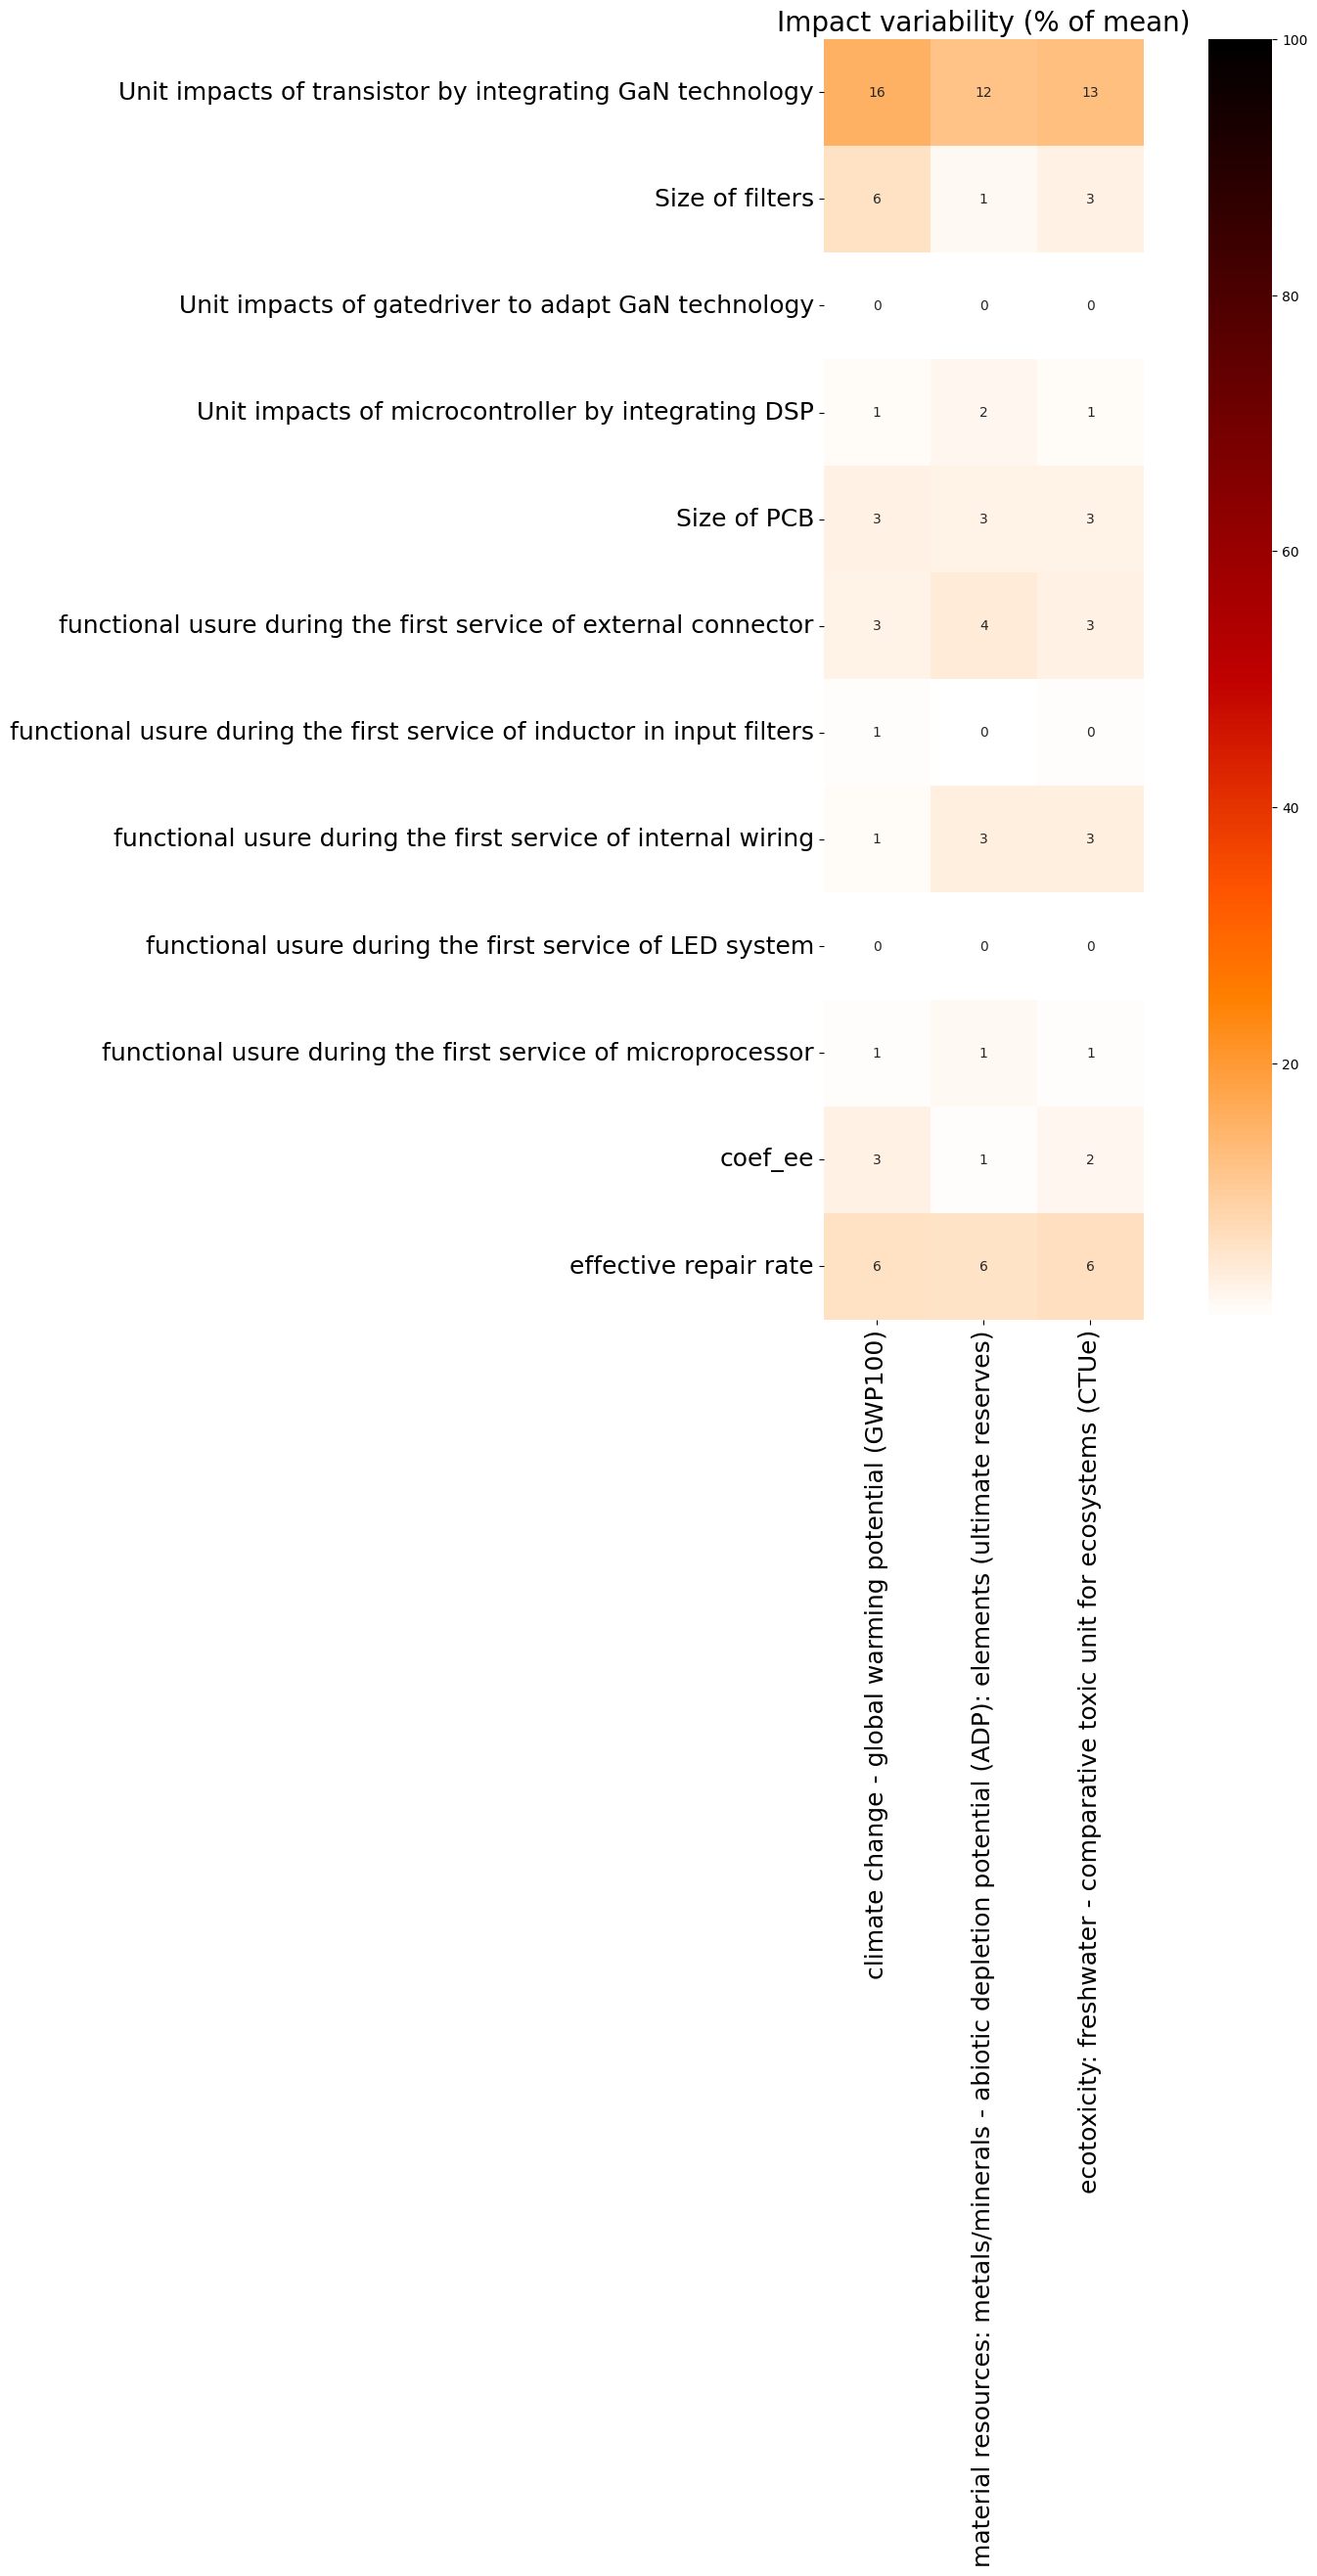

In [41]:
df=agb.oat_matrix(EI_total, impacts)
plt.savefig('2024-10-10-oat.png')
print(df)


